In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
DATA_DIR = Path("../data/raw")

participants = pd.read_csv(DATA_DIR / "participants_v1.csv")
responses = pd.read_csv(DATA_DIR / "survey_responses_v1.csv")

participants.shape, responses.shape


((300, 6), (300, 8))

In [3]:
df = responses.merge(
    participants,
    on=["participant_id", "condition_id", "condition_label"],
    how="left"
)

df.head()


,participant_id,condition_id,condition_label,comfort,trust,agency,adoption_intent,opt_out,privacy_sensitivity,tech_familiarity,baseline_trust
0,P001,granular_control,Granular control,5,2,4,1,1,3,1,1
1,P002,binary_control,Binary control,2,3,2,2,1,3,2,1
2,P003,granular_control,Granular control,2,4,4,2,0,1,1,3
3,P004,granular_control,Granular control,3,4,4,2,0,1,3,3
4,P005,granular_control,Granular control,4,4,5,3,0,3,1,3


In [4]:
df.shape

(300, 11)

In [5]:
df.groupby("condition_id")["agency"].mean().sort_values(ascending=False)

condition_id
granular_control    3.97
binary_control      2.73
no_control          2.11
Name: agency, dtype: float64

In [6]:
df[["agency", "trust"]].corr()

,agency,trust
agency,1.000000,0.132275
trust,0.132275,1.000000


In [7]:
df.describe()

,comfort,trust,agency,adoption_intent,opt_out,privacy_sensitivity,tech_familiarity,baseline_trust
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2.860000,2.576667,2.936667,2.553333,0.213333,2.036667,1.943333,2.023333
std,0.981637,1.086919,1.162106,0.978270,0.410346,0.827206,0.809717,0.831722
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,0.000000,1.000000,1.000000,1.000000
50%,3.000000,2.000000,3.000000,3.000000,0.000000,2.000000,2.000000,2.000000
75%,3.000000,3.000000,4.000000,3.000000,0.000000,3.000000,3.000000,3.000000
max,5.000000,5.000000,5.000000,5.000000,1.000000,3.000000,3.000000,3.000000


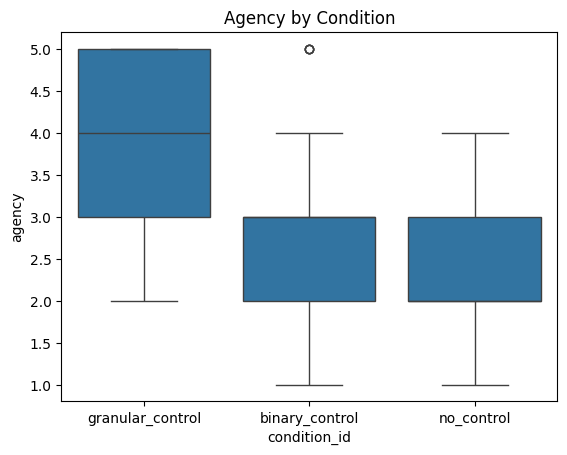

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="condition_id", y="agency")
plt.title("Agency by Condition")
plt.show()


In [9]:
df.groupby("condition_id")["agency"].median()

condition_id
binary_control      3.0
granular_control    4.0
no_control          2.0
Name: agency, dtype: float64

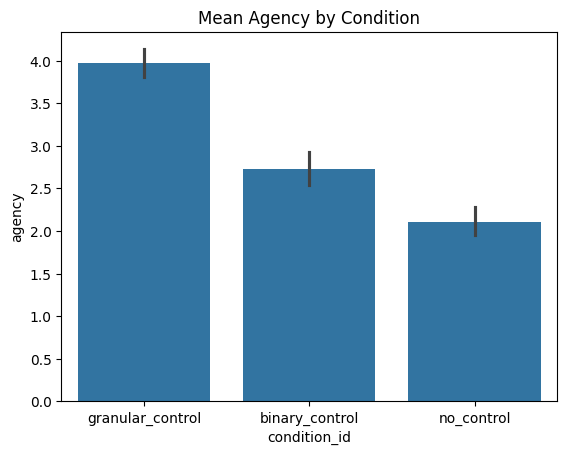

In [10]:
sns.barplot(data=df, x="condition_id", y="agency")
plt.title("Mean Agency by Condition")
plt.show()

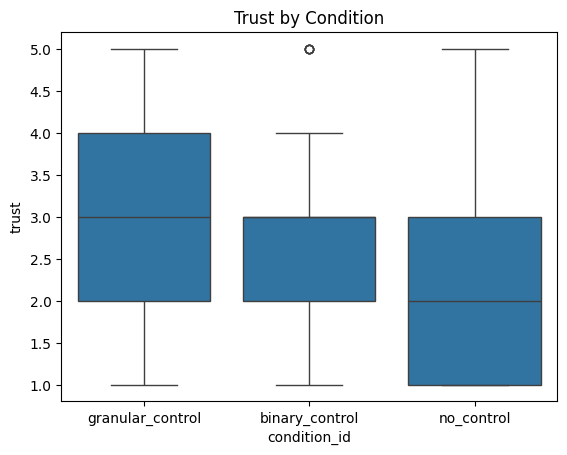

In [11]:
sns.boxplot(data=df, x="condition_id", y="trust")
plt.title("Trust by Condition")
plt.show()


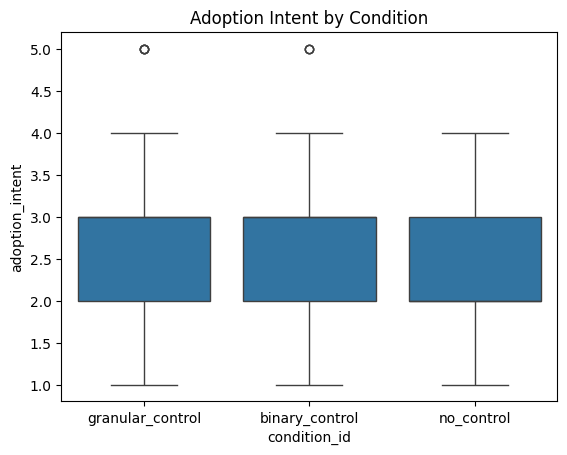

In [12]:
sns.boxplot(data=df, x="condition_id", y="adoption_intent")
plt.title("Adoption Intent by Condition")
plt.show()

In [13]:
df.groupby("condition_id")["adoption_intent"].mean()

condition_id
binary_control      2.69
granular_control    2.77
no_control          2.20
Name: adoption_intent, dtype: float64

In [14]:
df.groupby("condition_id")["opt_out"].mean()

condition_id
binary_control      0.31
granular_control    0.07
no_control          0.26
Name: opt_out, dtype: float64

In [15]:
df.columns

Index(['participant_id', 'condition_id', 'condition_label', 'comfort', 'trust',
       'agency', 'adoption_intent', 'opt_out', 'privacy_sensitivity',
       'tech_familiarity', 'baseline_trust'],
      dtype='str')

In [16]:
df.groupby("condition_id")["opt_out"].mean().sort_values(ascending=False)

condition_id
binary_control      0.31
no_control          0.26
granular_control    0.07
Name: opt_out, dtype: float64

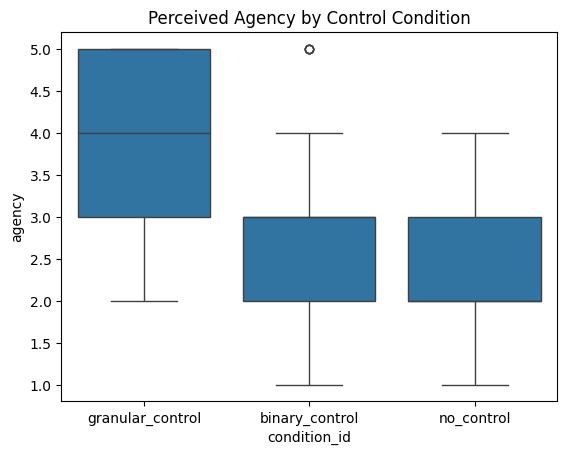

In [17]:
plt.figure()
sns.boxplot(data=df, x="condition_id", y="agency")
plt.title("Perceived Agency by Control Condition")
plt.savefig("../reports/figures/fig1_agency.png", bbox_inches="tight")
plt.show()

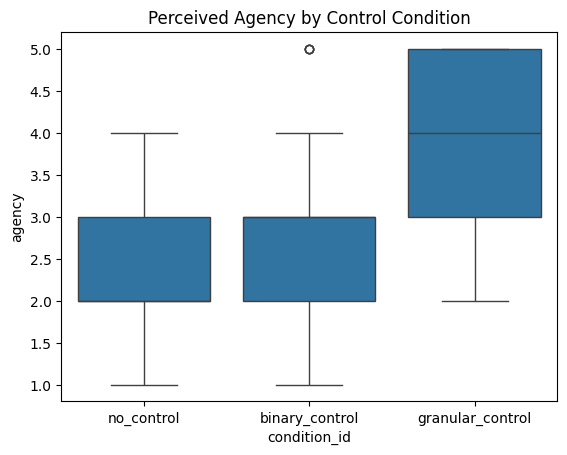

In [18]:
order = ["no_control", "binary_control", "granular_control"]

plt.figure()
sns.boxplot(
    data=df,
    x="condition_id",
    y="agency",
    order=order
)
plt.title("Perceived Agency by Control Condition")
plt.savefig("../reports/figures/fig1_agency.png", bbox_inches="tight")
plt.show()

/var/folders/9x/r_557n0979bgndwn3_2vxqbm0000gn/T/ipykernel_25770/1584414011.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[o] for o in order])


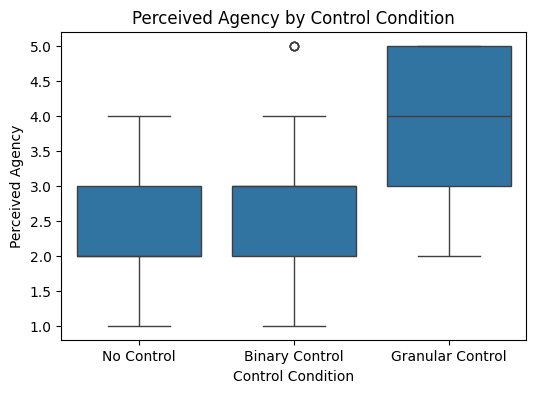

In [19]:
order = ["no_control", "binary_control", "granular_control"]
label_map = {
    "no_control": "No Control",
    "binary_control": "Binary Control",
    "granular_control": "Granular Control"
}

plt.figure(figsize=(6,4))
ax = sns.boxplot(
    data=df,
    x="condition_id",
    y="agency",
    order=order
)

ax.set_xticklabels([label_map[o] for o in order])
plt.xlabel("Control Condition")
plt.ylabel("Perceived Agency")
plt.title("Perceived Agency by Control Condition")

plt.savefig("../reports/figures/fig1_agency.png", bbox_inches="tight", dpi=300)
plt.show()

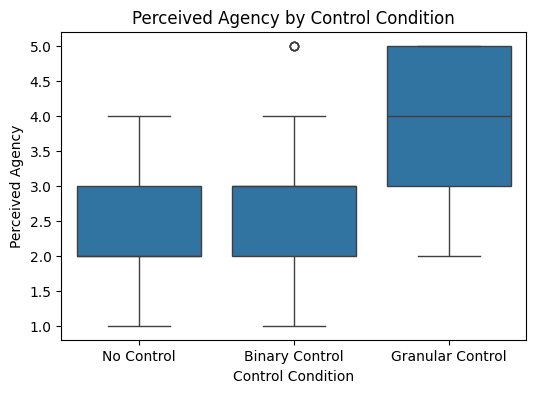

In [20]:
order = ["no_control", "binary_control", "granular_control"]
label_map = {
    "no_control": "No Control",
    "binary_control": "Binary Control",
    "granular_control": "Granular Control"
}

plt.figure(figsize=(6,4))
ax = sns.boxplot(
    data=df,
    x="condition_id",
    y="agency",
    order=order
)

ax.set_xlabel("Control Condition")
ax.set_ylabel("Perceived Agency")
ax.set_title("Perceived Agency by Control Condition")

# Fix tick positions before setting labels
ax.set_xticks(range(len(order)))
ax.set_xticklabels([label_map[o] for o in order])

plt.savefig("../reports/figures/fig1_agency.png", bbox_inches="tight", dpi=300)
plt.show()

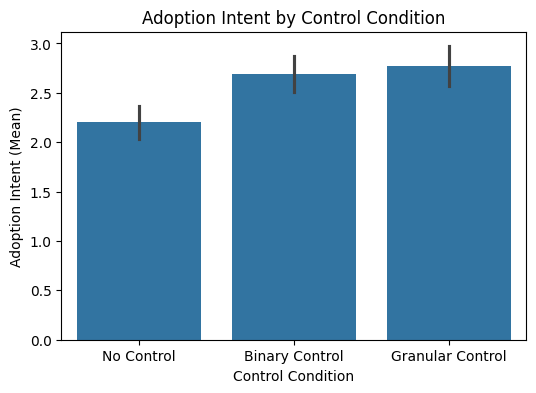

In [21]:
order = ["no_control", "binary_control", "granular_control"]
label_map = {
    "no_control": "No Control",
    "binary_control": "Binary Control",
    "granular_control": "Granular Control"
}

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df,
    x="condition_id",
    y="adoption_intent",
    order=order
)

ax.set_xlabel("Control Condition")
ax.set_ylabel("Adoption Intent (Mean)")
ax.set_title("Adoption Intent by Control Condition")

ax.set_xticks(range(len(order)))
ax.set_xticklabels([label_map[o] for o in order])

plt.savefig("../reports/figures/fig2_adoption.png", bbox_inches="tight", dpi=300)
plt.show()

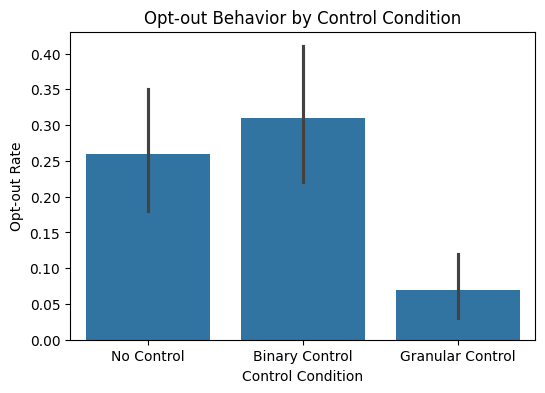

In [22]:
order = ["no_control", "binary_control", "granular_control"]
label_map = {
    "no_control": "No Control",
    "binary_control": "Binary Control",
    "granular_control": "Granular Control"
}

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=df,
    x="condition_id",
    y="opt_out",
    order=order
)

ax.set_xlabel("Control Condition")
ax.set_ylabel("Opt-out Rate")
ax.set_title("Opt-out Behavior by Control Condition")

ax.set_xticks(range(len(order)))
ax.set_xticklabels([label_map[o] for o in order])

plt.savefig("../reports/figures/fig3_optout.png", bbox_inches="tight", dpi=300)
plt.show()